# 04 · Rug model and machine learning

Point-in-time snapshots, forward labels, purged forward-chaining cross-validation, explainability, and the guard that stops a model from scoring the data it was trained on.

> **Real data instead of the synthetic market.** Replace the generation cell with
> ```python
> from pumpfun_hft.collectors.storage import ParquetEventStore
> from pumpfun_hft.backtester.replay import load_metadata
> events = ParquetEventStore(settings.paths.events_dir).read()
> metadata = load_metadata(settings.paths.metadata_dir / "tokens.parquet")
> ```
> after running `collect-history` (or `stream`) from the CLI.


In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, polars as pl, matplotlib.pyplot as plt
from pumpfun_hft.core.config import load_settings
from pumpfun_hft.collectors.synthetic import SyntheticMarket

pl.Config.set_tbl_rows(12); pl.Config.set_tbl_cols(14); pl.Config.set_fmt_str_lengths(40); pl.Config.set_tbl_width_chars(160)
BLUE, ORANGE, AQUA, YELLOW, RED, GRAY = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e34948", "#898781"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.color": "#e1e0d9", "grid.linewidth": 0.6, "axes.edgecolor": "#c3c2b7", "font.size": 9})


In [2]:
settings = load_settings(None, {"synthetic.duration_hours": 24})
data = SyntheticMarket(settings).generate()
from pumpfun_hft.ml.dataset import build_snapshot_dataset, feature_columns
ds = build_snapshot_dataset(settings, data.events, {r["mint"]: r for r in data.metadata.iter_rows(named=True)})
cols = feature_columns(ds)
print(f"{ds.height:,} snapshots × {len(cols)} features · rug base rate {ds['rug'].mean():.3f}")
ds.select("mint", "delay_s", "snapshot_ms", "label_end_ms", "snap_liq", "min_liq", "rug", "fwd_return").head(6)

2,856 snapshots × 61 features · rug base rate 0.314


mint,delay_s,snapshot_ms,label_end_ms,snap_liq,min_liq,rug,fwd_return
str,f64,i64,i64,f64,f64,i8,f64
"""6GiEdwwQxDZMCR7oePDhF5VZSaQbbMH7VtvXobPB…",10.0,1788220998801,1788222798801,15.929668,2.898065,1,-0.496319
"""6GiEdwwQxDZMCR7oePDhF5VZSaQbbMH7VtvXobPB…",30.0,1788221018801,1788222818801,18.406528,2.898065,1,-0.763328
"""6GiEdwwQxDZMCR7oePDhF5VZSaQbbMH7VtvXobPB…",60.0,1788221048801,1788222848801,7.430695,2.898065,0,-0.249041
"""6GiEdwwQxDZMCR7oePDhF5VZSaQbbMH7VtvXobPB…",120.0,1788221108801,1788222908801,7.081478,2.734154,0,-0.230294
"""2nAeMk7KbwMzYJL6MNJgihbhBrTbxGEjtEj1dBoU…",10.0,1788221218001,1788223018001,12.73092,0.604083,1,-0.667579
"""2nAeMk7KbwMzYJL6MNJgihbhBrTbxGEjtEj1dBoU…",30.0,1788221238001,1788223038001,10.246183,0.604083,1,-0.547763


Each row is a token observed `delay_s` seconds after launch, with features computed from the online state at that instant. The `rug` label (liquidity falls ≥ 80 % below the snapshot within 30 minutes) comes only from later events, and `label_end_ms` lets cross-validation purge overlaps.

In [3]:
from pumpfun_hft.ml.models import train_and_evaluate
reports = {kind: train_and_evaluate(ds, cols, "rug", settings.ml.model_copy(update={"model": kind}), settings.app.seed)
           for kind in ("logistic", "lightgbm")}
pl.DataFrame([{"model": k, **{m: r.mean.get(m) for m in ("auc", "log_loss", "brier", "precision_top_decile", "base_rate")}}
              for k, r in reports.items()])

Background dataset has 300 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=300 when initializing the masker.


model,auc,log_loss,brier,precision_top_decile,base_rate
str,f64,f64,f64,f64,f64
"""logistic""",0.81302,0.786766,0.208785,0.72807,0.320053
"""lightgbm""",0.825025,0.656855,0.175212,0.785088,0.320053


In [4]:
pl.DataFrame(reports["lightgbm"].folds).select("fold", "n_train", "n_test", "base_rate", "auc", "precision_top_decile")

fold,n_train,n_test,base_rate,auc,precision_top_decile
f64,f64,f64,f64,f64,f64
0.0,500.0,571.0,0.299475,0.780731,0.754386
1.0,1072.0,571.0,0.339755,0.799352,0.684211
2.0,1650.0,571.0,0.322242,0.869144,0.877193
3.0,2246.0,571.0,0.318739,0.850871,0.824561


Training rows always end before the test block starts (purged + embargoed), and tokens never appear on both sides. Later folds train on more history.

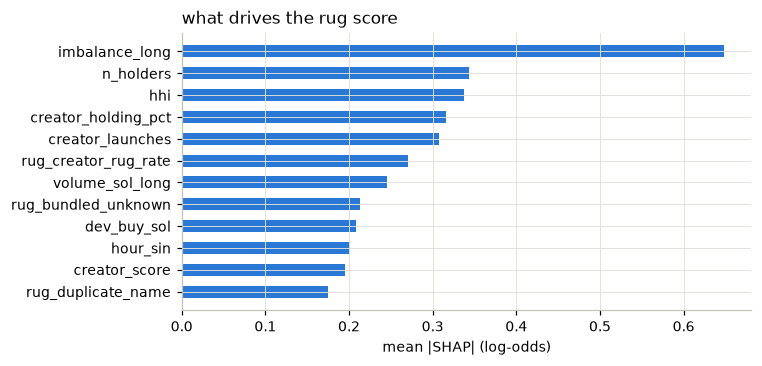

In [5]:
imp = reports["lightgbm"].importance.sort("shap", descending=True, nulls_last=True).head(12)
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.barh(imp["feature"][::-1], imp["shap"][::-1], color=BLUE, height=0.55)
ax.set_xlabel("mean |SHAP| (log-odds)"); ax.set_title("what drives the rug score", loc="left"); plt.tight_layout(); plt.show()

## The look-ahead guard
A saved model records the last label time it saw. Scoring anything earlier raises `LookAheadError`, so a model can never be backtested on its own training data.

In [6]:
import tempfile
from pathlib import Path
from pumpfun_hft.ml.rug_model import LookAheadError, TrainedRugModel
path = reports["logistic"].save(Path(tempfile.mkdtemp()) / "rug.joblib")
model = TrainedRugModel.load(path)
x = {f: 0.0 for f in model.features}
print("score after the cut-off:", round(model.predict(x, now_ms=model.train_end_ms + 1), 4))
try:
    model.predict(x, now_ms=model.train_end_ms - 1)
except LookAheadError as e:
    print("refused:", e)

score after the cut-off: 0.0083
refused: model trained through 1788309012401 used at 1788309012400
